In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [33]:
X, y_true = make_blobs(n_samples = 500, centers = 3, cluster_std = 4, random_state = 42)

In [34]:
X

array([[-2.28253389e+00, -9.69281529e+00],
       [-6.14766774e+00,  1.75599022e+00],
       [ 1.33990906e+01, -1.26002346e+00],
       [-4.07763024e+00,  3.16022634e+00],
       [ 9.44473452e+00,  3.40868192e-01],
       [ 7.96122210e+00, -1.45116562e+00],
       [ 3.36071096e+00, -7.26434919e+00],
       [ 5.72170614e+00,  1.77221725e+00],
       [ 3.69397119e-01,  1.40365174e+00],
       [-9.37890150e+00, -6.77574539e+00],
       [ 2.05358730e+00, -2.35302233e+00],
       [ 2.12518469e+00,  5.73155685e+00],
       [ 6.02293588e+00,  1.20593493e+00],
       [-2.25635580e-01,  1.35565487e+01],
       [ 5.79897826e+00,  1.02747729e+01],
       [ 8.87357678e+00, -5.06178826e+00],
       [-2.79723811e+00,  1.30284177e+01],
       [-1.13705153e+01, -5.35047061e+00],
       [-6.55049123e+00, -2.61818809e+00],
       [-6.93453752e+00,  4.22945963e+00],
       [-9.54391459e-01,  4.22504663e+00],
       [-1.67374324e+00,  1.17560563e+00],
       [ 6.94610669e+00,  3.21817030e+00],
       [-6.

In [ ]:
df = pd.DataFrame(X, columns = [ 'Feature_1', 'Feature_2' ])

In [36]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [38]:
inertia = []
k_range = range(1,11)

In [ ]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [40]:
inertia

[1000.0000000000002,
 528.8064432605652,
 294.4377068678189,
 250.45524696534466,
 216.88110656982622,
 185.2744067519592,
 156.7087999629046,
 135.62603453115258,
 129.10396348239823,
 119.94101297104999]

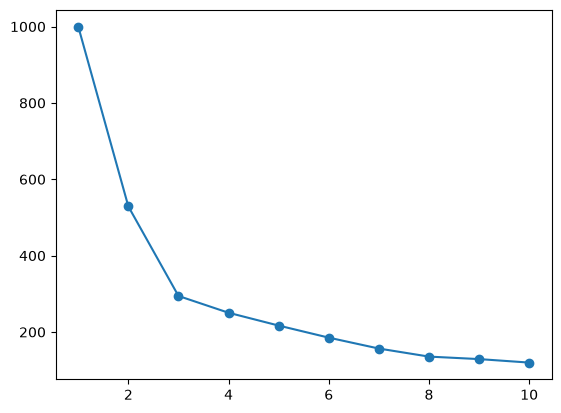

In [41]:
plt.plot(k_range , inertia, marker = 'o')

In [42]:
kmeans_final = KMeans(n_clusters = 3, random_state = 42)

In [43]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [ ]:
df['cluster_labels'] =cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

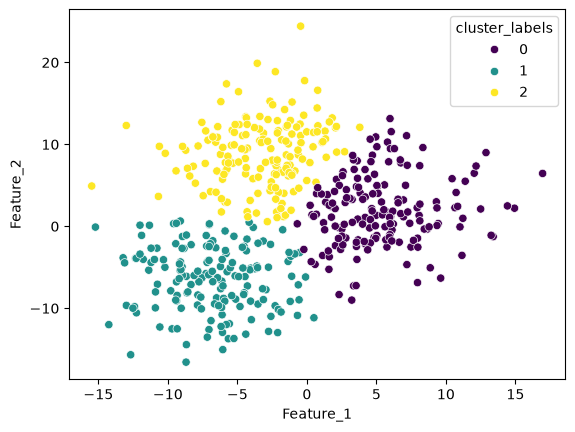

In [45]:
sns.scatterplot(x = df['Feature_1'],
                y = df['Feature_2'],
                hue = df['cluster_labels'],
                palette = 'viridis')

In [46]:
from sklearn.datasets import make_moons

In [47]:
X, y_true = make_moons(n_samples = 500, noise = 0.05, random_state = 42)

In [48]:
from sklearn.cluster import DBSCAN

In [49]:
df = pd.DataFrame(X, columns = [ 'Feature_1', 'Feature_2' ])

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [52]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:
df['kmeans_labels'] =kmeans_labels

# Disadvantage of KMeans

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

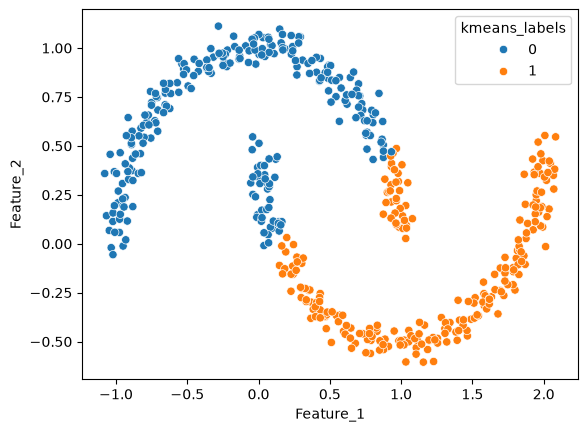

In [ ]:
sns.scatterplot(x = df['Feature_1'],
                y = df['Feature_2'],
                hue = df['kmeans_labels'])

# Use of DBSCAN

In [56]:
dbscan = DBSCAN(eps = 0.3, min_samples = 5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
df['dbscan_labels'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

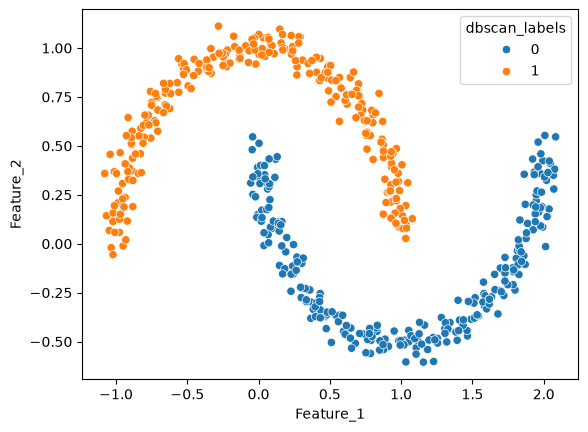

In [58]:
sns.scatterplot(x = df['Feature_1'],
                y = df['Feature_2'],
                hue = df['dbscan_labels'])